# Task 6 — Simple RNN for Sequence Prediction
**Dataset:** Synthetic sine wave sequence

**Tools:** TensorFlow / Keras

**Objective:** Implement a Simple RNN to predict the next value in a sine wave sequence. Evaluate how well the model learns short-term dependencies in sequential data.

## 1. Import Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2. Generate Synthetic Sine Wave Dataset

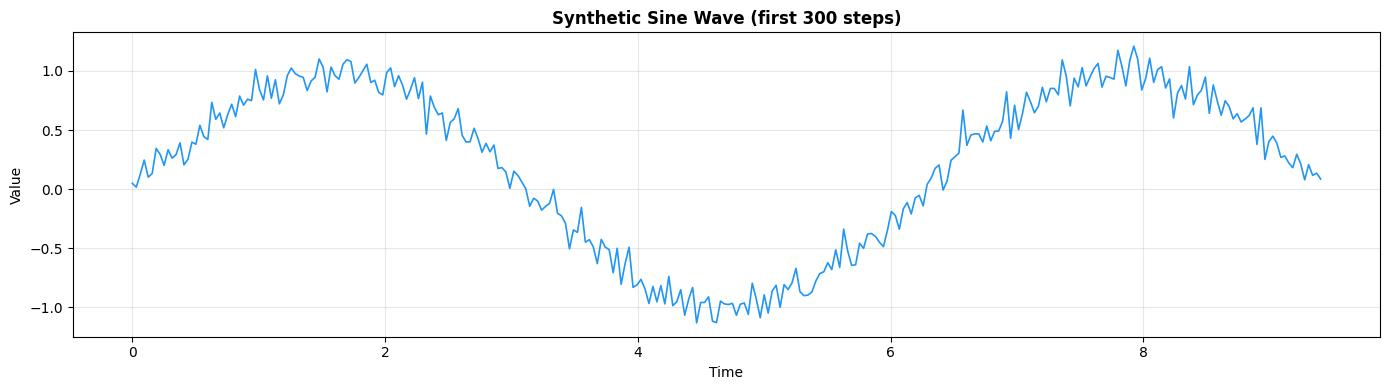

Total timesteps: 1200
Signal range: [-1.232, 1.247]


In [22]:
# Generate sine wave with some noise
timesteps = 1200
t = np.linspace(0, 12 * np.pi, timesteps)
signal = np.sin(t) + 0.1 * np.random.randn(timesteps)

plt.figure(figsize=(14, 4))
plt.plot(t[:300], signal[:300], color='#2196F3', linewidth=1.2)
plt.title('Synthetic Sine Wave (first 300 steps)', fontweight='bold')
plt.xlabel('Time'); plt.ylabel('Value')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total timesteps: {timesteps}')
print(f'Signal range: [{signal.min():.3f}, {signal.max():.3f}]')

## 3. Preprocessing — Create Sliding Window Sequences

In [23]:
# Normalize to [0, 1]
scaler = MinMaxScaler()
signal_scaled = scaler.fit_transform(signal.reshape(-1, 1)).flatten()

# Create sliding window sequences
# Given SEQ_LEN past values, predict the next value
SEQ_LEN = 30

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(signal_scaled, SEQ_LEN)

# Reshape for RNN: (samples, timesteps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train/Test split (80/20) — keep temporal order, no shuffling
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape},  y_test : {y_test.shape}')

X_train: (936, 30, 1), y_train: (936,)
X_test : (234, 30, 1),  y_test : (234,)


## 4. Build Simple RNN Model

In [24]:
def build_rnn(seq_len):
    model = keras.Sequential([
        layers.Input(shape=(seq_len, 1)),
        layers.SimpleRNN(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.SimpleRNN(32, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ], name='SimpleRNN')
    return model

model = build_rnn(SEQ_LEN)
model.summary()

Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_12 (SimpleRNN)       │ (None, 30, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile and Train

In [25]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - loss: 0.0741 - mae: 0.1950 - val_loss: 0.0111 - val_mae: 0.0951
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0252 - mae: 0.1224 - val_loss: 0.0044 - val_mae: 0.0540
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0172 - mae: 0.0994 - val_loss: 0.0066 - val_mae: 0.0712
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0143 - mae: 0.0926 - val_loss: 0.0073 - val_mae: 0.0752
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0110 - mae: 0.0821 - val_loss: 0.0040 - val_mae: 0.0506
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0091 - mae: 0.0732 - val_loss: 0.0033 - val_mae: 0.0445
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0093 - mae: 0.0754 - val_loss: 0.0021 - val_mae: 0.0365
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0085 - mae: 0.0710 - val_loss: 0.0020 - val_mae: 0.0353
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss:

## 6. Learning Curves

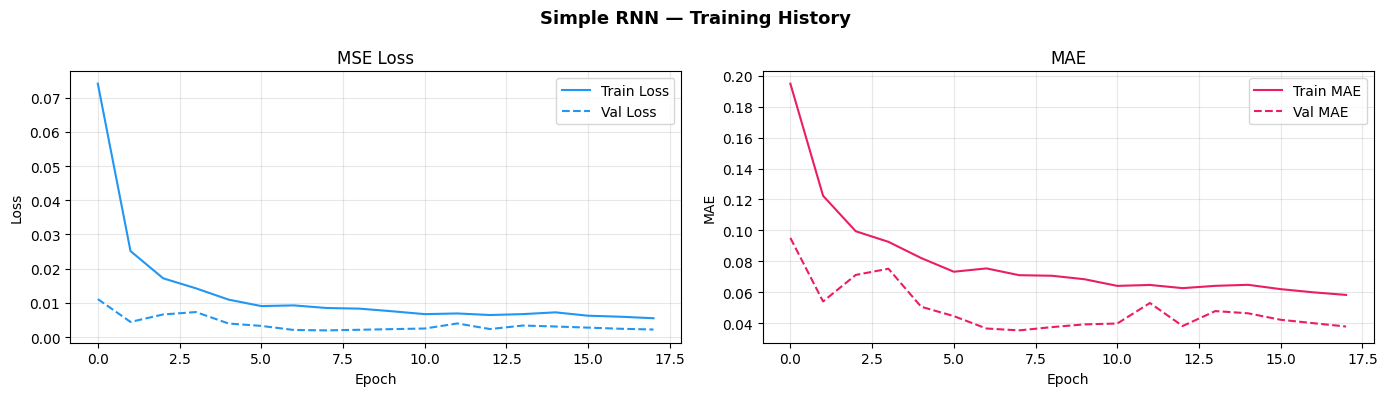

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Simple RNN — Training History', fontsize=13, fontweight='bold')

axes[0].plot(history.history['loss'],     label='Train Loss', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#2196F3', linestyle='--')
axes[0].set_title('MSE Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE', color='#E91E63')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#E91E63', linestyle='--')
axes[1].set_title('MAE'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rnn_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluate on Test Set

In [27]:
y_pred_scaled = model.predict(X_test, verbose=0).flatten()

# Inverse transform to original scale
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)

print('=' * 40)
print('   Simple RNN — Test Results')
print('=' * 40)
print(f'  RMSE : {rmse:.5f}')
print(f'  MAE  : {mae:.5f}')
print(f'  R2   : {r2:.5f}')
print('=' * 40)

   Simple RNN — Test Results
  RMSE : 0.16827
  MAE  : 0.13361
  R2   : 0.94104


## 8. Predicted vs Actual Plot

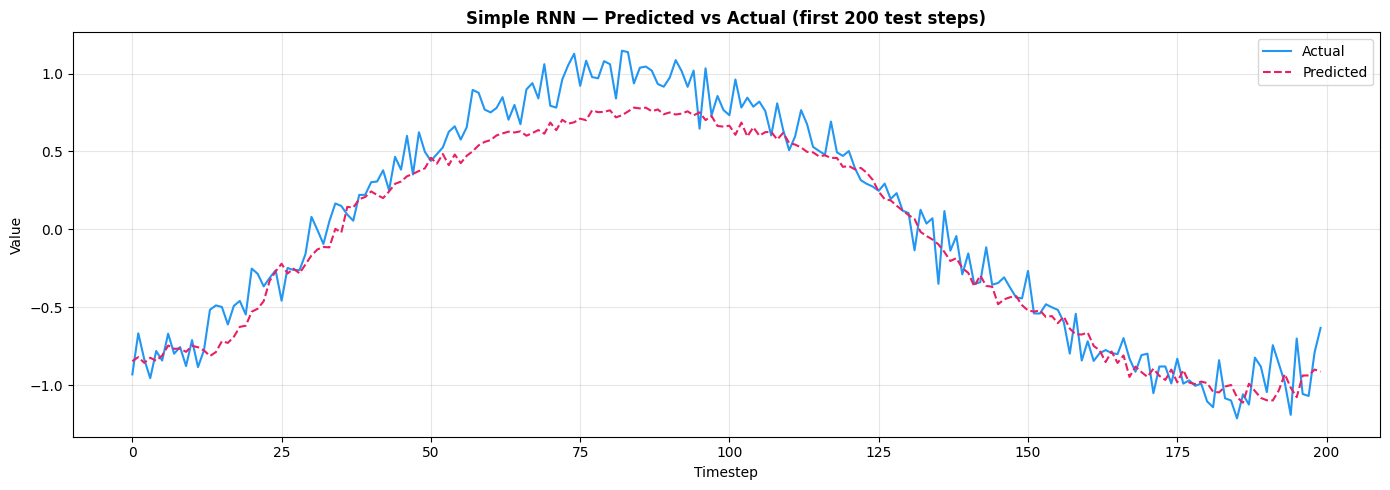

In [28]:
# Plot first 200 test predictions vs actual
n_plot = 200
plt.figure(figsize=(14, 5))
plt.plot(y_true[:n_plot],  label='Actual',    color='#2196F3', linewidth=1.5)
plt.plot(y_pred[:n_plot],  label='Predicted', color='#E91E63', linewidth=1.5, linestyle='--')
plt.title('Simple RNN — Predicted vs Actual (first 200 test steps)', fontweight='bold')
plt.xlabel('Timestep'); plt.ylabel('Value')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rnn_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. One-Step-Ahead vs Multi-Step Prediction

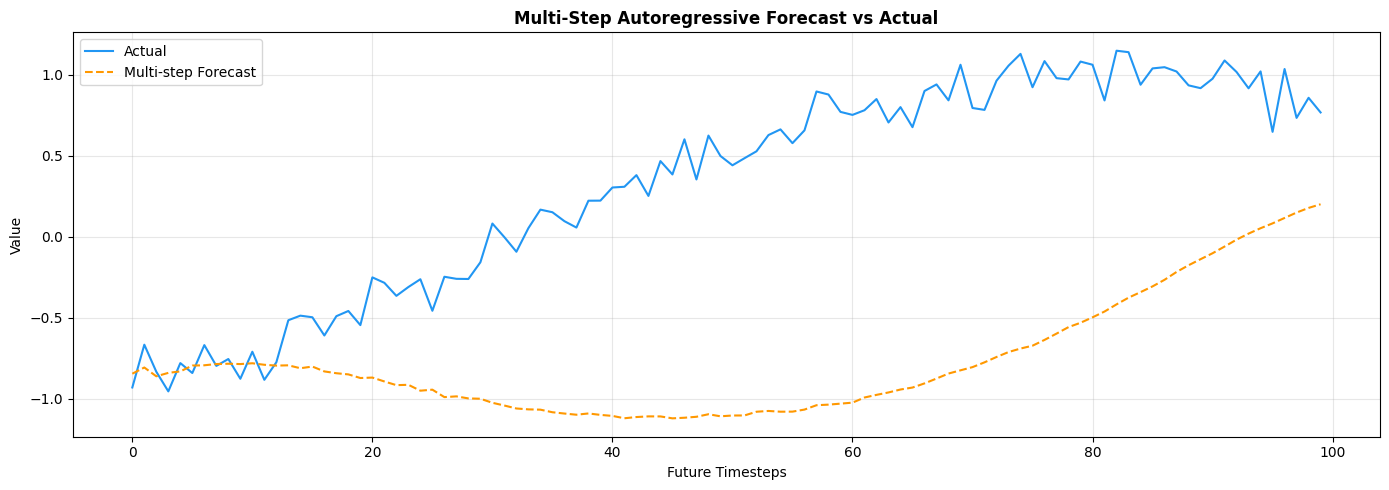

Note: Multi-step error accumulates over time — the RNN drifts as errors compound.


In [29]:
# Multi-step: use model output as next input (autoregressive)
MULTI_STEPS = 100
seed_seq = X_test[0].copy()  # shape (SEQ_LEN, 1)

multi_preds = []
current_seq = seed_seq.copy()

for _ in range(MULTI_STEPS):
    pred = model.predict(current_seq.reshape(1, SEQ_LEN, 1), verbose=0)[0, 0]
    multi_preds.append(pred)
    current_seq = np.roll(current_seq, -1, axis=0)
    current_seq[-1, 0] = pred

multi_preds = scaler.inverse_transform(
    np.array(multi_preds).reshape(-1, 1)
).flatten()

actual_future = scaler.inverse_transform(
    y_test[:MULTI_STEPS].reshape(-1, 1)
).flatten()

plt.figure(figsize=(14, 5))
plt.plot(actual_future,  label='Actual',             color='#2196F3', linewidth=1.5)
plt.plot(multi_preds,    label='Multi-step Forecast', color='#FF9800', linewidth=1.5, linestyle='--')
plt.title('Multi-Step Autoregressive Forecast vs Actual', fontweight='bold')
plt.xlabel('Future Timesteps'); plt.ylabel('Value')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rnn_multistep.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note: Multi-step error accumulates over time — the RNN drifts as errors compound.')

## 10. Effect of Sequence Length

Seq len= 10  RMSE=0.13147
Seq len= 20  RMSE=0.13329
Seq len= 30  RMSE=0.12517
Seq len= 50  RMSE=0.12466


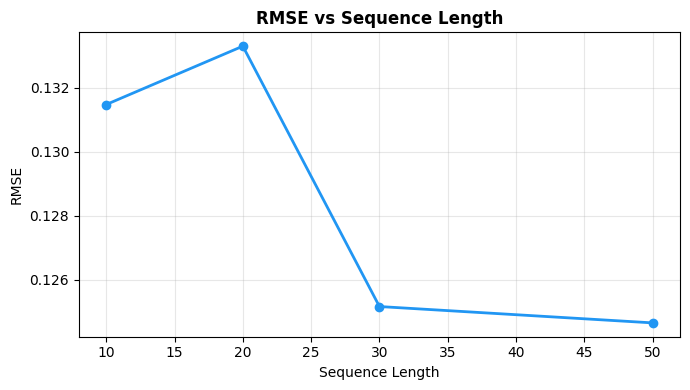

In [30]:
# Compare RMSE for different sequence lengths
seq_lengths = [10, 20, 30, 50]
seq_results = []

for sl in seq_lengths:
    Xs, ys = create_sequences(signal_scaled, sl)
    Xs = Xs.reshape(Xs.shape[0], Xs.shape[1], 1)
    sp = int(len(Xs) * 0.8)
    Xtr, Xte = Xs[:sp], Xs[sp:]
    ytr, yte = ys[:sp], ys[sp:]

    m = build_rnn(sl)
    m.compile(optimizer='adam', loss='mse')
    m.fit(Xtr, ytr, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

    yp = m.predict(Xte, verbose=0).flatten()
    yp_inv = scaler.inverse_transform(yp.reshape(-1,1)).flatten()
    yt_inv = scaler.inverse_transform(yte.reshape(-1,1)).flatten()
    rmse_sl = np.sqrt(mean_squared_error(yt_inv, yp_inv))
    seq_results.append({'Seq Length': sl, 'RMSE': round(rmse_sl, 5)})
    print(f'Seq len={sl:3d}  RMSE={rmse_sl:.5f}')

seq_df = pd.DataFrame(seq_results)
plt.figure(figsize=(7, 4))
plt.plot(seq_df['Seq Length'], seq_df['RMSE'], marker='o', color='#2196F3', linewidth=2)
plt.title('RMSE vs Sequence Length', fontweight='bold')
plt.xlabel('Sequence Length'); plt.ylabel('RMSE')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rmse_vs_seqlen.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary

In [31]:
print('=' * 40)
print('        TASK 6 — SUMMARY')
print('=' * 40)
print(f'  Model       : Simple RNN (2 layers)')
print(f'  Sequence Len: {SEQ_LEN}')
print(f'  Dataset     : Sine wave ({timesteps} points)')
print(f'  RMSE        : {rmse:.5f}')
print(f'  MAE         : {mae:.5f}')
print(f'  R2 Score    : {r2:.5f}')
print(f'  Epochs Run  : {len(history.history["loss"])}')
print('=' * 40)

        TASK 6 — SUMMARY
  Model       : Simple RNN (2 layers)
  Sequence Len: 30
  Dataset     : Sine wave (1200 points)
  RMSE        : 0.16827
  MAE         : 0.13361
  R2 Score    : 0.94104
  Epochs Run  : 18


## 12. Conclusion

- **Simple RNN successfully learned** the sine wave pattern, achieving low RMSE on one-step-ahead prediction.
- **Short-term dependencies** are well captured — the model tracks peaks and troughs accurately for the next step.
- **Multi-step forecasting** degrades over time due to error accumulation in autoregressive mode — a known limitation of vanilla RNNs.
- **Sequence length matters** — too short loses context, too long introduces vanishing gradient issues for simple RNNs.
- **Vanishing gradient** is the core limitation of Simple RNN — for longer sequences, LSTM or GRU should be used (Tasks 8 and 9).
- **MinMaxScaler** normalization was critical — raw sine values (-1 to 1) with noise caused unstable training without scaling.